## M0  Setup

In [3]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'config.yaml').exists() and (ROOT.parent / 'config.yaml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from m0_setup.config import load_config

print('environment ready')

environment ready


## Parameters  edit here, then Run All

These override `config.yaml` for this notebook run. Any key you leave out keeps
the value from `config.yaml`. Changing the dates or the stock list refreshes the
raw snapshot automatically (the cache notices the change). Anything you change
flows through every stage below.

Notes:
- `n_folds × test_size` trading days are held out, oldest first.
- `explain_sample_size` caps how many test rows SHAP explains per fold.
- A full run is a few minutes; the LSTM is not part of the MVP.

In [4]:
# ---- tunable parameters: edit here, then Run All ----
# Any key left out keeps its value from config.yaml.
PARAMS = {
    'seed': 42,
    'data': {
        'start_date': '2015-01-01',
        'end_date': '2026-09-19',
        'stocks': ['BHP', 'CBA', 'CSL', 'NAB', 'WBC', 'ANZ', 'WES', 'RIO', 'MQG', 'TLS'],
        'force_download': False,
    },
    'features': {
        'rsi_window': 14,
        'sma_windows': [10, 20, 50],
        'ema_windows': [12, 26],
        'return_lags': [1, 2, 3, 5],
    },
    'walk_forward': {'n_folds': 8, 'val_size': 60, 'test_size': 120, 'min_train_size': 500},
    'models': {
        'logistic': {'C': 1.0, 'max_iter': 1000, 'class_weight': 'balanced'},
        'xgboost': {
            'n_estimators': 300,
            'max_depth': 4,
            'learning_rate': 0.05,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_lambda': 1.0,
        },
    },
    'shap': {'explain_sample_size': 2000},
    'consistency': {'rolling_window': 120, 'diagnostic_window': 60, 'top_k': 10},
    'faithfulness': {'top_k': 5},
}

cfg = load_config(ROOT / 'config.yaml', overrides=PARAMS)
print('effective parameters')
print('  seed:', cfg['seed'], '| stocks:', len(cfg['data']['stocks']), '| folds:', cfg['walk_forward']['n_folds'])
print('  dates:', cfg['data']['start_date'], '->', cfg['data']['end_date'])
print('  xgboost:', cfg['models']['xgboost'])
print('  results dir:', cfg['paths']['results'])

effective parameters
  seed: 42 | stocks: 10 | folds: 8
  dates: 2015-01-01 -> 2026-09-19
  xgboost: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'eval_metric': 'logloss'}
  results dir: C:\Users\Md Tanvir Hasan\OneDrive\Documents\Obsidian Vault\Courses\MQ\Project\COMP8851 Major Project - Internal Project and Internship streams\explainable-stock-trend-xai\results


## M1  Data acquisition (SP1)

In [5]:
from m1_data.data_collection import run as run_data

coverage = run_data(cfg)
coverage

BHP.AX: 2967 rows saved
CBA.AX: 2967 rows saved
CSL.AX: 2967 rows saved
NAB.AX: 2967 rows saved
WBC.AX: 2967 rows saved
ANZ.AX: 2967 rows saved
WES.AX: 2967 rows saved
RIO.AX: 2967 rows saved
MQG.AX: 2967 rows saved
TLS.AX: 2967 rows saved
^AXJO: 2964 rows saved
^AXVI: 2965 rows saved
RBA macro: 3977 rows saved

   series  rows      start        end  missing_pct
   BHP.AX  2967 2015-01-02 2026-09-18         0.00
   CBA.AX  2967 2015-01-02 2026-09-18         0.00
   CSL.AX  2967 2015-01-02 2026-09-18         0.00
   NAB.AX  2967 2015-01-02 2026-09-18         0.00
   WBC.AX  2967 2015-01-02 2026-09-18         0.00
   ANZ.AX  2967 2015-01-02 2026-09-18         0.00
   WES.AX  2967 2015-01-02 2026-09-18         0.00
   RIO.AX  2967 2015-01-02 2026-09-18         0.00
   MQG.AX  2967 2015-01-02 2026-09-18         0.00
   TLS.AX  2967 2015-01-02 2026-09-18         0.00
    ^AXJO  2964 2015-01-02 2026-09-18         0.00
    ^AXVI  2965 2015-01-02 2026-09-18         0.00
RBA_macro  3977 2011-01

,series,rows,start,end,missing_pct
0,BHP.AX,2967,2015-01-02,2026-09-18,0.00
1,CBA.AX,2967,2015-01-02,2026-09-18,0.00
2,CSL.AX,2967,2015-01-02,2026-09-18,0.00
3,NAB.AX,2967,2015-01-02,2026-09-18,0.00
4,WBC.AX,2967,2015-01-02,2026-09-18,0.00
5,ANZ.AX,2967,2015-01-02,2026-09-18,0.00
6,WES.AX,2967,2015-01-02,2026-09-18,0.00
7,RIO.AX,2967,2015-01-02,2026-09-18,0.00
8,MQG.AX,2967,2015-01-02,2026-09-18,0.00
9,TLS.AX,2967,2015-01-02,2026-09-18,0.00


## M2  Preprocessing, features and target (SP2)

In [6]:
from m2_features.features import run as run_features, feature_columns

table = run_features(cfg)
print('rows:', len(table), '| features:', len(feature_columns(cfg)))
table.head(3)

panel: 29670 rows x 16 cols -> panel.parquet
model table: 28955 rows x 29 features
target balance: 0.517 up
date range: 2015-03-13 .. 2026-09-17
rows: 28955 | features: 29


,date,Adj Close,Close,High,Low,Open,Volume,stock,market_ret,market_rv_21,...,close_sma_50,close_ema_12,close_ema_26,bb_pctb,bb_bandwidth,atr_14,rv_21,volume_change_5,volume_ratio_20,target
0,2015-03-13,18.625591,35.159542,35.526615,35.020649,35.367882,2817131,ANZ,-0.006102,0.007680,...,0.045607,0.002334,0.012994,0.607093,0.030796,0.865682,0.009065,-0.126242,0.580590,1.0
1,2015-03-16,18.683409,35.268673,35.397644,34.921440,35.219067,3079808,ANZ,-0.002889,0.005674,...,0.046802,0.004604,0.014925,0.746136,0.027905,0.865481,0.007711,0.008323,0.634816,1.0
2,2015-03-17,18.872601,35.625824,35.764713,35.486931,35.536533,4052637,ANZ,0.007658,0.005936,...,0.055078,0.012475,0.023292,1.017605,0.030411,0.860254,0.007998,0.140033,0.886683,1.0


## M3  Chronological walk-forward folds (SP3a)

In [7]:
from m3_walkforward.validation import walk_forward_folds

folds = walk_forward_folds(table['date'], cfg)
pd.DataFrame([
    {
        'fold': fold.index,
        'train_days': len(fold.train),
        'val_days': len(fold.val),
        'test_start': pd.Timestamp(fold.test.min()).date(),
        'test_end': pd.Timestamp(fold.test.max()).date(),
    }
    for fold in folds
])

,fold,train_days,val_days,test_start,test_end
0,0,1878,60,2022-11-24,2023-05-19
1,1,1998,60,2023-05-22,2023-11-07
2,2,2118,60,2023-11-08,2024-05-02
3,3,2238,60,2024-05-03,2024-10-21
4,4,2358,60,2024-10-22,2025-04-11
5,5,2478,60,2025-04-14,2025-10-02
6,6,2598,60,2025-10-03,2026-03-30
7,7,2718,60,2026-03-31,2026-09-17


## M4  LogReg + XGBoost and walk-forward metrics (SP3b)

In [8]:
from m4_models.models import run as run_models

predictions = run_models(cfg)
print('\nPooled metrics')
display(pd.read_csv(Path(cfg['paths']['tables']) / 'model_metrics_pooled.csv').round(4))
print('Naive baselines')
display(pd.read_csv(Path(cfg['paths']['tables']) / 'baseline_metrics.csv').round(4))

   model    n  accuracy  precision   recall       f1  roc_auc       mcc
logistic 9598  0.502084   0.518887 0.615031 0.562883 0.495913 -0.006026
 xgboost 9598  0.505835   0.521900 0.619228 0.566414 0.497977  0.001646

Pooled metrics


,model,n,accuracy,precision,recall,f1,roc_auc,mcc
0,logistic,9598,0.5021,0.5189,0.6150,0.5629,0.4959,-0.0060
1,xgboost,9598,0.5058,0.5219,0.6192,0.5664,0.4980,0.0016


Naive baselines


,model,n,accuracy,precision,recall,f1,roc_auc,mcc
0,majority_class,9598,0.5213,0.5213,1.0000,0.6853,0.5000,0.0000
1,persistence,9598,0.4898,0.5102,0.5305,0.5201,0.4964,-0.0241


## M6  SHAP attributions (SP4)

In [9]:
from m6_shap.explainability import run as run_shap

shap_frames = run_shap(cfg)
importance = pd.read_csv(Path(cfg['paths']['tables']) / 'shap_global_importance.csv')
print('\nTop 10 by mean |SHAP| — XGBoost')
display(importance[importance['model'] == 'xgboost'].head(10)[['rank', 'feature', 'mean_abs_shap']].round(4))

Background dataset has 18757 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=18757 when initializing the masker.


fold 0: explained 1200 test rows for both models


Background dataset has 19957 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=19957 when initializing the masker.


fold 1: explained 1200 test rows for both models


Background dataset has 21157 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=21157 when initializing the masker.


...

Background dataset has 25955 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=25955 when initializing the masker.


fold 6: explained 1200 test rows for both models


Background dataset has 27155 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=27155 when initializing the masker.


fold 7: explained 1200 test rows for both models

Top 10 by mean |SHAP| — XGBoost


,rank,feature,mean_abs_shap
0,1,bond_10y,0.1235
1,2,term_spread,0.0989
2,3,vix,0.0879
3,4,market_ret,0.0789
4,5,bond_2y,0.0772
5,6,market_rv_21,0.0753
6,7,vix_change_5,0.0631
7,8,cash_rate,0.0542
8,9,macd_signal,0.0356
9,10,atr_14,0.0320


## M7  Financial groups and direction of effect (SP5)

In [10]:
from m7_interpretation.interpretation import run as run_interpretation

interpretation = run_interpretation(cfg)
interpretation['group_importance'][['model', 'group', 'share_pct', 'rank']].round(2)

   model               group  mean_abs_group_shap  share_pct  rank
logistic            momentum             0.081141  28.200000     1
logistic               trend             0.079053  27.480000     2
logistic   market_conditions             0.054134  18.820000     3
logistic          volatility             0.038160  13.260000     4
logistic economic_conditions             0.020102   6.990000     5
logistic    trading_activity             0.015127   5.260000     6
 xgboost economic_conditions             0.211588  35.380001     1
 xgboost   market_conditions             0.161683  27.040001     2
 xgboost            momentum             0.093460  15.630000     3
 xgboost               trend             0.054276   9.080000     4
 xgboost          volatility             0.047360   7.920000     5
 xgboost    trading_activity             0.029614   4.950000     6


,model,group,share_pct,rank
6,logistic,momentum,28.20,1
7,logistic,trend,27.48,2
9,logistic,market_conditions,18.82,3
8,logistic,volatility,13.26,4
11,logistic,economic_conditions,6.99,5
10,logistic,trading_activity,5.26,6
5,xgboost,economic_conditions,35.38,1
3,xgboost,market_conditions,27.04,2
0,xgboost,momentum,15.63,3
1,xgboost,trend,9.08,4


## M8  Two-level consistency, diagnostic and abstention (SP6a/SP6b)

In [11]:
from m8_consistency.consistency import run as run_consistency

consistency = run_consistency(cfg)
consistency['summary'].round(4)

Feature-level vs group-level stability (mean over comparisons)
                  topk_overlap  spearman  cosine    marc
model    level                                          
logistic feature        0.8731    0.9388  0.9845  1.9310
         group          0.9615    0.9347  0.9875  0.3333
xgboost  feature        0.8462    0.8299  0.8902  3.6158
         group          0.8846    0.9102  0.9672  0.4762


topk_overlap  spearman  cosine    marc
model    level                                          
logistic feature        0.8731    0.9388  0.9845  1.9310
         group          0.9615    0.9347  0.9875  0.3333
xgboost  feature        0.8462    0.8299  0.8902  3.6158
         group          0.8846    0.9102  0.9672  0.4762

In [12]:
from m8_consistency.diagnostic import run as run_diagnostic

diagnostic = run_diagnostic(cfg)
diagnostic['summary'].round(4)

   model    n  auc_consistency_vs_correct  auc_confidence_vs_correct  accuracy_low_consistency  accuracy_high_consistency  accuracy_all
 xgboost 9548                      0.4881                     0.4968                    0.5142                     0.4977        0.5060
logistic 9548                      0.5097                     0.5013                    0.4998                     0.5050        0.5024


,model,n,auc_consistency_vs_correct,auc_confidence_vs_correct,accuracy_low_consistency,accuracy_high_consistency,accuracy_all
0,xgboost,9548,0.4881,0.4968,0.5142,0.4977,0.5060
1,logistic,9548,0.5097,0.5013,0.4998,0.5050,0.5024


## M9  Faithfulness: permutation and placebo (SP6)

In [13]:
from m9_faithfulness.faithfulness import run as run_faithfulness

faithfulness = run_faithfulness(cfg)
print('\nPlacebo rank among all features (lower is more faithful)')
display(faithfulness['placebo'].round(4))

Background dataset has 27155 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=27155 when initializing the masker.


   model  bottom    top  ratio_top_over_bottom
logistic  0.0019 0.0465                23.9892
 xgboost  0.0079 0.0240                 3.0443

   model  fold  placebo_rank  n_features  placebo_mean_abs_shap  top_feature  top_mean_abs_shap
logistic     7            21          30                 0.0108 close_sma_20             0.3589
 xgboost     7            23          30                 0.0212      bond_2y             0.2677

Placebo rank among all features (lower is more faithful)


,model,fold,placebo_rank,n_features,placebo_mean_abs_shap,top_feature,top_mean_abs_shap
0,logistic,7,21,30,0.0108,close_sma_20,0.3589
1,xgboost,7,23,30,0.0212,bond_2y,0.2677


## M10  Decision-support prototype (SP7)

In [14]:
from m10_prototype.prototype import explain_stock, interpretation_text

prediction = explain_stock('BHP', cfg)
print(interpretation_text(prediction))
prediction.group_shares.round(1).to_frame('group_share_pct')

The model leans upward on BHP for the next trading day (62.8% probability of an up move, as of 2026-09-17). The strongest financial theme behind this call is economic conditions. Explanation consistency against the recent window is 0.76 (in line with recent reasoning). Research demonstration only — this is not trading advice.


,group_share_pct
momentum,3.500000
trend,15.200000
volatility,20.799999
market_conditions,12.200000
trading_activity,2.900000
economic_conditions,45.400002


## M11 Figures, tables and manifest

In [15]:
from m11_results.plotting import run as run_figures

figures = run_figures(cfg)
print('\ngenerated:', ', '.join(Path(p).name for p in figures))

c:\Users\Md Tanvir Hasan\OneDrive\Documents\Obsidian Vault\Courses\MQ\Project\COMP8851 Major Project - Internal Project and Internship streams\explainable-stock-trend-xai\m11_results\plotting.py:123: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values, data, max_display=15, show=False)


wrote rq1_performance_vs_baselines.png
wrote rq1_performance_by_fold.png
wrote rq1_performance_by_regime.png
wrote rq2_shap_importance.png
wrote rq2_shap_beeswarm_xgboost.png
wrote rq3_group_importance.png
wrote rq4a_stability_levels.png
wrote rq4a_group_by_regime_xgboost.png
wrote rq4b_risk_coverage.png

generated: rq1_performance_vs_baselines.png, rq1_performance_by_fold.png, rq1_performance_by_regime.png, rq2_shap_importance.png, rq2_shap_beeswarm_xgboost.png, rq3_group_importance.png, rq4a_stability_levels.png, rq4a_group_by_regime_xgboost.png, rq4b_risk_coverage.png


rq4a_stability_levels.png


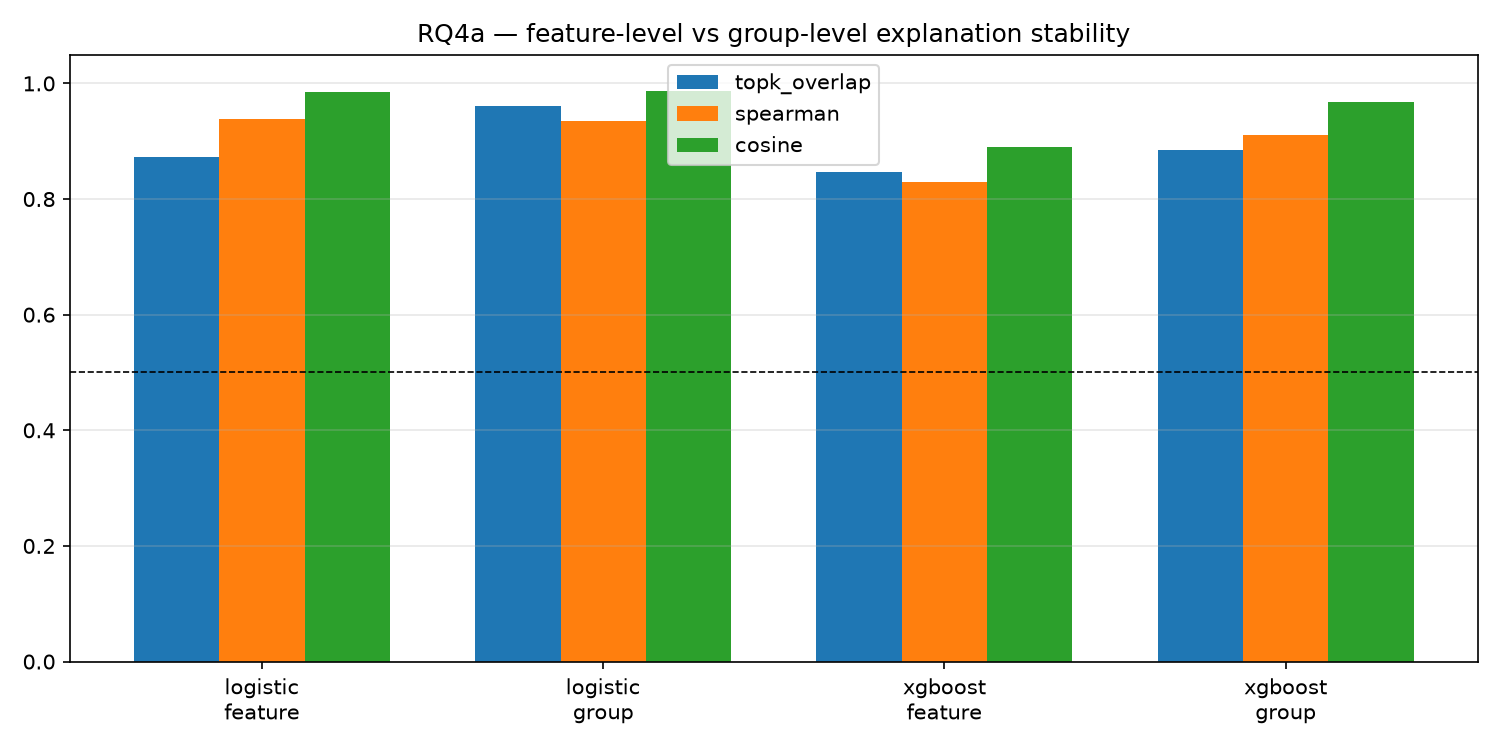

rq4b_risk_coverage.png


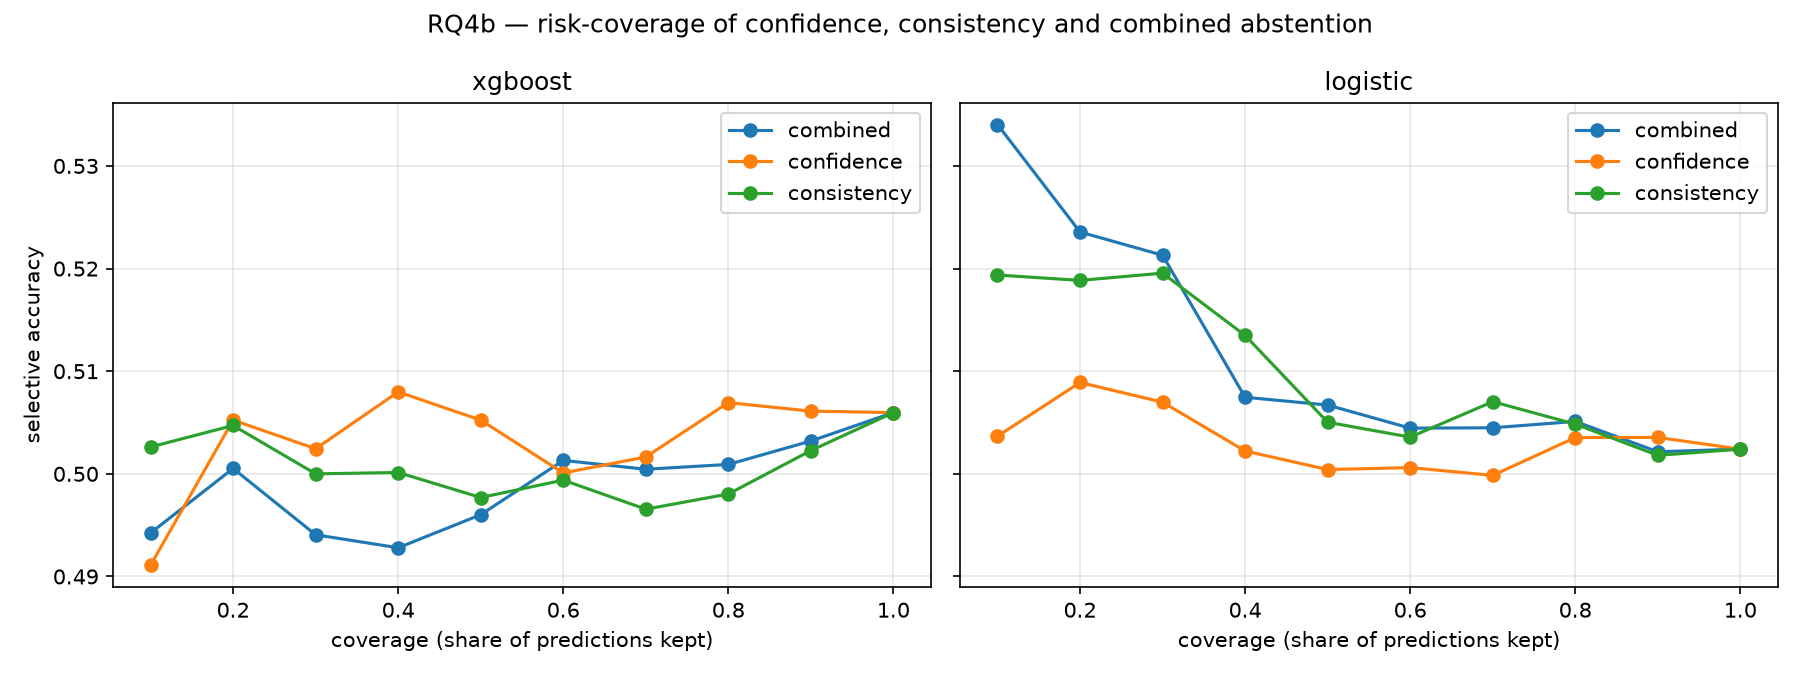

In [16]:
from IPython.display import Image, display

figures_dir = Path(cfg['paths']['figures'])
for name in ('rq4a_stability_levels.png', 'rq4b_risk_coverage.png'):
    print(name)
    display(Image(filename=str(figures_dir / name)))

## Verification

The leakage and correctness tests run as part of the milestone, not after it.

In [17]:
import subprocess

result = subprocess.run(
    [sys.executable, '-m', 'pytest', '-q'], cwd=str(ROOT), capture_output=True, text=True
)
print(result.stdout.strip().splitlines()[-1])

29 passed, 3 warnings in 4.85s
